In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv("CognifyDataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [21]:
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [22]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [23]:
drop_cols = [
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality Verbose',
    'Rating color',
    'Rating text'
]

df = df.drop(columns=drop_cols)

print(df.columns)

Index(['Country Code', 'City', 'Locality', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')


In [24]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes
0,162,73,171,121.027535,14.565443,920,1100,0,1,0,0,0,3,4.8,314
1,162,73,593,121.014101,14.553708,1111,1200,0,1,0,0,0,3,4.5,591
2,162,75,308,121.056831,14.581404,1671,4000,0,1,0,0,0,4,4.4,270
3,162,75,862,121.056475,14.585318,1126,1500,0,0,0,0,0,4,4.9,365
4,162,75,862,121.057508,14.584450,1122,1500,0,1,0,0,0,4,4.8,229


In [25]:
X = df.drop('Aggregate rating', axis=1)

y = df['Aggregate rating']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (9551, 14)
Target Shape: (9551,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (7640, 14)
Testing Shape: (1911, 14)


In [27]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [28]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("===== Linear Regression =====")
print("Mean Squared Error:", mse_lr)
print("R² Score:", r2_lr)

===== Linear Regression =====
Mean Squared Error: 1.5598013254120158
R² Score: 0.31470710231677923


In [29]:
dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [30]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("===== Decision Tree Regression =====")
print("Mean Squared Error:", mse_dt)
print("R² Score:", r2_dt)

===== Decision Tree Regression =====
Mean Squared Error: 0.10798943573415706
R² Score: 0.9525552439738513


In [31]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MSE': [mse_lr, mse_dt],
    'R2 Score': [r2_lr, r2_dt]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,1.559801,0.314707
1,Decision Tree,0.107989,0.952555


In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
13,Votes,0.971489
3,Longitude,0.011623
4,Latitude,0.005395
5,Cuisines,0.004726
6,Average Cost for two,0.002981
1,City,0.001697
2,Locality,0.001129
7,Currency,0.000505
12,Price range,0.000207
9,Has Online delivery,0.000108


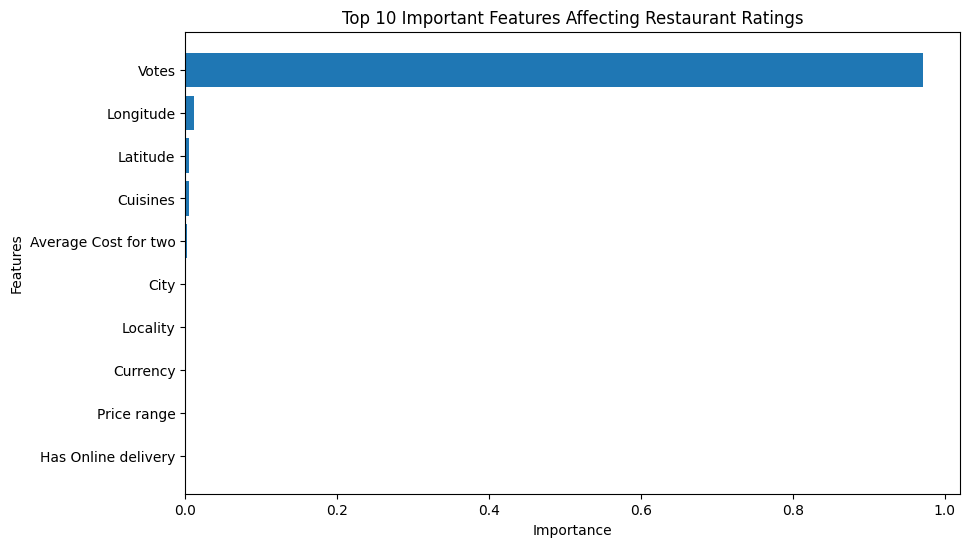

In [33]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features Affecting Restaurant Ratings")

plt.gca().invert_yaxis()

plt.show()

In [34]:
print("Top Influential Features:\n")

for feature, imp in zip(
    importance['Feature'].head(10),
    importance['Importance'].head(10)
):
    print(f"{feature}: {imp:.4f}")

Top Influential Features:

Votes: 0.9715
Longitude: 0.0116
Latitude: 0.0054
Cuisines: 0.0047
Average Cost for two: 0.0030
City: 0.0017
Locality: 0.0011
Currency: 0.0005
Price range: 0.0002
Has Online delivery: 0.0001


In [35]:
print("===== Linear Regression =====")
print("Mean Squared Error:", mse_lr)
print("R² Score:", r2_lr)

print("\n===== Decision Tree Regression =====")
print("Mean Squared Error:", mse_dt)
print("R² Score:", r2_dt)

===== Linear Regression =====
Mean Squared Error: 1.5598013254120158
R² Score: 0.31470710231677923

===== Decision Tree Regression =====
Mean Squared Error: 0.10798943573415706
R² Score: 0.9525552439738513
